# 📊 Notebook 1: Exploratory Data Analysis & Preprocessing
**Project**: Early Alzheimer's Prediction Using EEG Signals

**Dataset**: OpenNeuro ds004504 — 88 subjects, eyes-closed resting-state EEG

**Groups**: Alzheimer's Disease (A, n=36) | Healthy Controls (C, n=29) | Frontotemporal Dementia (F, n=23)

This notebook performs:
1. Demographic analysis of the patient cohort
2. Raw EEG signal exploration and visualization
3. Preprocessing pipeline (filtering, epoching, artifact rejection)
4. Spectral analysis and band power extraction
5. Saving preprocessed data for deep learning models

In [1]:
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy import signal as scipy_signal
from pathlib import Path
import warnings
import json
import os
import time

warnings.filterwarnings('ignore')
mne.set_log_level('ERROR')

plt.rcParams.update({
    'figure.figsize': (12, 6), 'figure.dpi': 100, 'font.size': 12,
    'axes.titlesize': 14, 'axes.labelsize': 12, 'figure.facecolor': 'white'
})
sns.set_style("whitegrid")
sns.set_palette("husl")

BASE_DIR = Path('/home/aditya11/Documents/playground/be_proj_final')
DATA_DIR = BASE_DIR / 'ds004504'
DERIV_DIR = DATA_DIR / 'derivatives'
RESULTS_DIR = BASE_DIR / 'results'
PROCESSED_DIR = BASE_DIR / 'processed_data'
RESULTS_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(exist_ok=True)

print("✅ Environment ready")
print(f"   MNE version: {mne.__version__}")
import torch
print(f"   PyTorch version: {torch.__version__}")
print(f"   CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Environment ready
   MNE version: 1.10.1


   PyTorch version: 2.2.0+cu121
   CUDA available: True
   GPU: NVIDIA GeForce RTX 4050 Laptop GPU


## 1. Dataset Demographics Analysis
We analyze the distribution of Age, Gender, and MMSE (Mini-Mental State Examination) scores across the three clinical groups.

In [2]:
participants = pd.read_csv(DATA_DIR / 'participants.tsv', sep='\t')
participants.columns = participants.columns.str.strip()

group_map = {'A': 'Alzheimer\'s (AD)', 'C': 'Control (HC)', 'F': 'FTD'}
label_map = {'A': 0, 'C': 1, 'F': 2}
participants['GroupName'] = participants['Group'].map(group_map)
participants['Label'] = participants['Group'].map(label_map)

print(f"Total subjects: {len(participants)}")
print(f"\nGroup distribution:")
print(participants.groupby('GroupName').agg(
    Count=('participant_id', 'count'),
    Age_Mean=('Age', 'mean'), Age_Std=('Age', 'std'),
    MMSE_Mean=('MMSE', 'mean'), MMSE_Std=('MMSE', 'std')
).round(2))

Total subjects: 88

Group distribution:
                  Count  Age_Mean  Age_Std  MMSE_Mean  MMSE_Std
GroupName                                                      
Alzheimer's (AD)     36     66.39     7.89      17.75      4.50
Control (HC)         29     67.90     5.40      30.00      0.00
FTD                  23     63.65     8.22      22.17      2.64


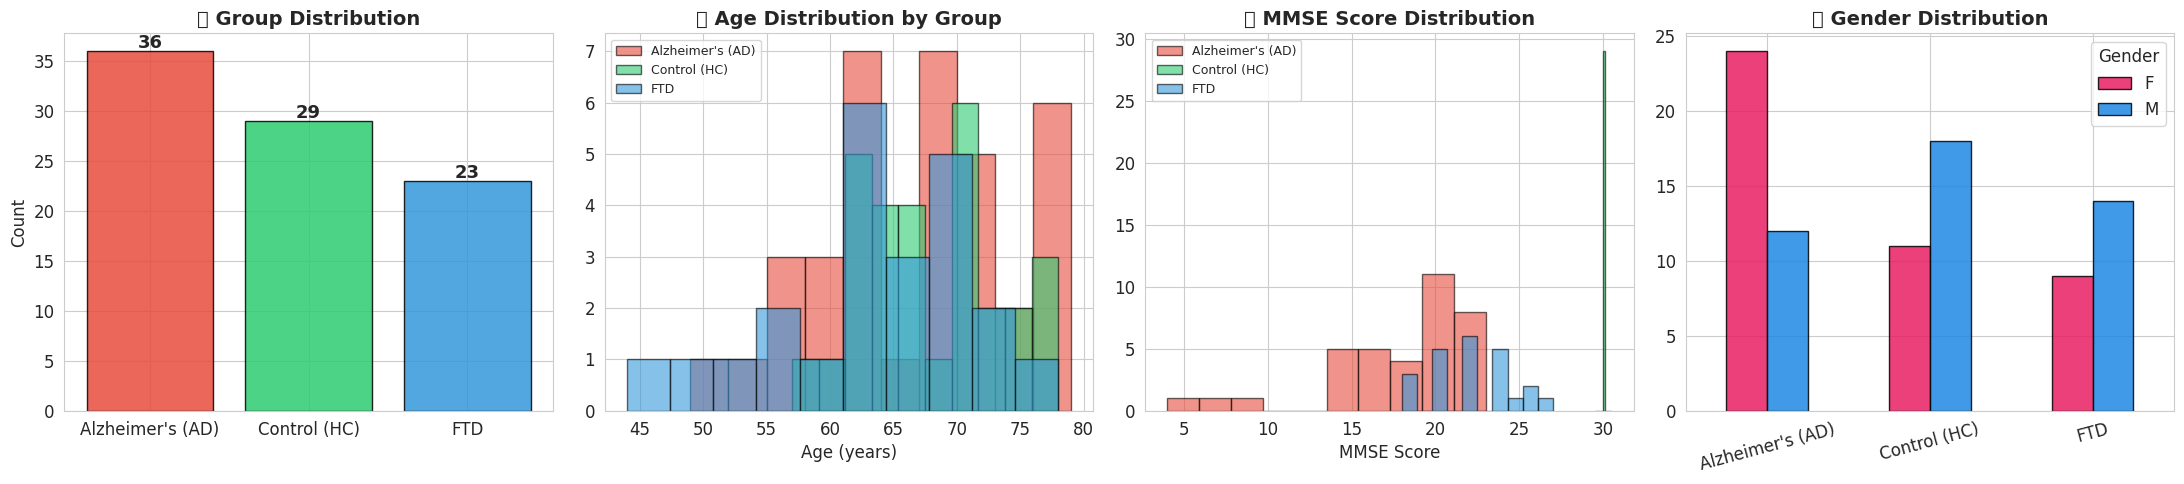

✅ Demographics figure saved


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
colors = {'Alzheimer\'s (AD)': '#e74c3c', 'Control (HC)': '#2ecc71', 'FTD': '#3498db'}

# Group distribution
grp_counts = participants['GroupName'].value_counts()
axes[0].bar(grp_counts.index, grp_counts.values, color=[colors[g] for g in grp_counts.index], edgecolor='black', alpha=0.85)
axes[0].set_title('📊 Group Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(grp_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=13)

# Age distribution
for grp, color in colors.items():
    data = participants[participants['GroupName'] == grp]['Age']
    axes[1].hist(data, bins=10, alpha=0.6, label=grp, color=color, edgecolor='black')
axes[1].set_title('📅 Age Distribution by Group', fontweight='bold')
axes[1].set_xlabel('Age (years)')
axes[1].legend(fontsize=9)

# MMSE distribution
for grp, color in colors.items():
    data = participants[participants['GroupName'] == grp]['MMSE']
    axes[2].hist(data, bins=10, alpha=0.6, label=grp, color=color, edgecolor='black')
axes[2].set_title('🧠 MMSE Score Distribution', fontweight='bold')
axes[2].set_xlabel('MMSE Score')
axes[2].legend(fontsize=9)

# Gender distribution
gender_grp = participants.groupby(['GroupName', 'Gender']).size().unstack(fill_value=0)
gender_grp.plot(kind='bar', ax=axes[3], color=['#e91e63', '#1e88e5'], edgecolor='black', alpha=0.85)
axes[3].set_title('👤 Gender Distribution', fontweight='bold')
axes[3].set_xlabel('')
axes[3].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'demographics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Demographics figure saved")

## 2. Raw EEG Signal Exploration
We load a sample EEG recording to understand the data structure, channel configuration, and signal characteristics.

In [4]:
sample_file = DERIV_DIR / 'sub-001' / 'eeg' / 'sub-001_task-eyesclosed_eeg.set'
raw_sample = mne.io.read_raw_eeglab(str(sample_file), preload=True, verbose=False)

print(f"📡 Sample EEG Info (sub-001, Alzheimer's patient):")
print(f"   Channels: {raw_sample.info['nchan']}")
print(f"   Channel names: {raw_sample.ch_names}")
print(f"   Sampling rate: {raw_sample.info['sfreq']} Hz")
print(f"   Duration: {raw_sample.times[-1]:.1f} seconds")
print(f"   Data shape: {raw_sample.get_data().shape}")

N_CHANNELS = raw_sample.info['nchan']
SFREQ_ORIG = raw_sample.info['sfreq']
CH_NAMES = raw_sample.ch_names

📡 Sample EEG Info (sub-001, Alzheimer's patient):
   Channels: 19
   Channel names: ['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T3', 'T4', 'T5', 'T6', 'Fz', 'Cz', 'Pz']
   Sampling rate: 500.0 Hz
   Duration: 599.8 seconds
   Data shape: (19, 299900)


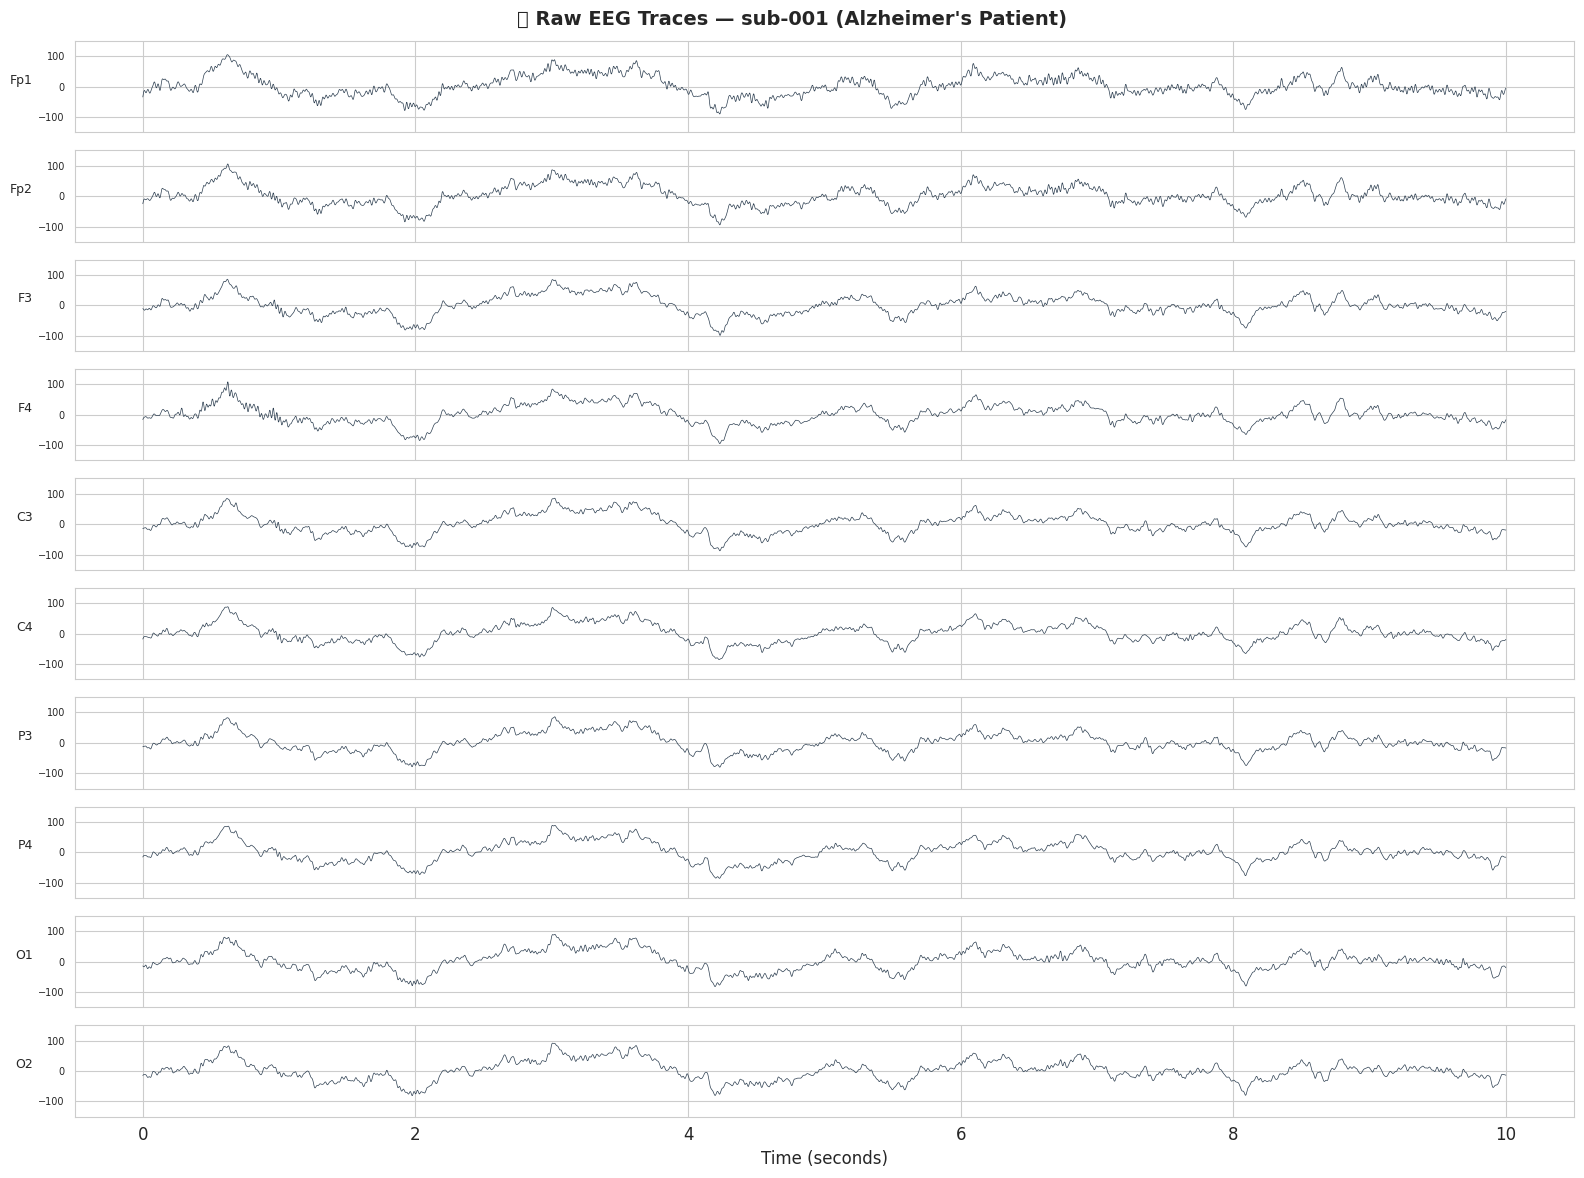

✅ Raw EEG traces plotted


In [5]:
# Plot raw EEG traces (first 10 seconds)
data = raw_sample.get_data()
times = raw_sample.times
n_show = min(10, len(CH_NAMES))
t_end = min(10, times[-1])
t_mask = times <= t_end

fig, axes = plt.subplots(n_show, 1, figsize=(16, 12), sharex=True)
scale = np.max(np.abs(data[:n_show, t_mask])) * 0.8

for i in range(n_show):
    axes[i].plot(times[t_mask], data[i, t_mask] * 1e6, linewidth=0.5, color='#2c3e50')
    axes[i].set_ylabel(CH_NAMES[i], fontsize=9, rotation=0, ha='right')
    axes[i].set_ylim([-150, 150])
    axes[i].tick_params(axis='y', labelsize=7)
axes[-1].set_xlabel('Time (seconds)')
fig.suptitle('🔬 Raw EEG Traces — sub-001 (Alzheimer\'s Patient)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'raw_eeg_traces.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Raw EEG traces plotted")

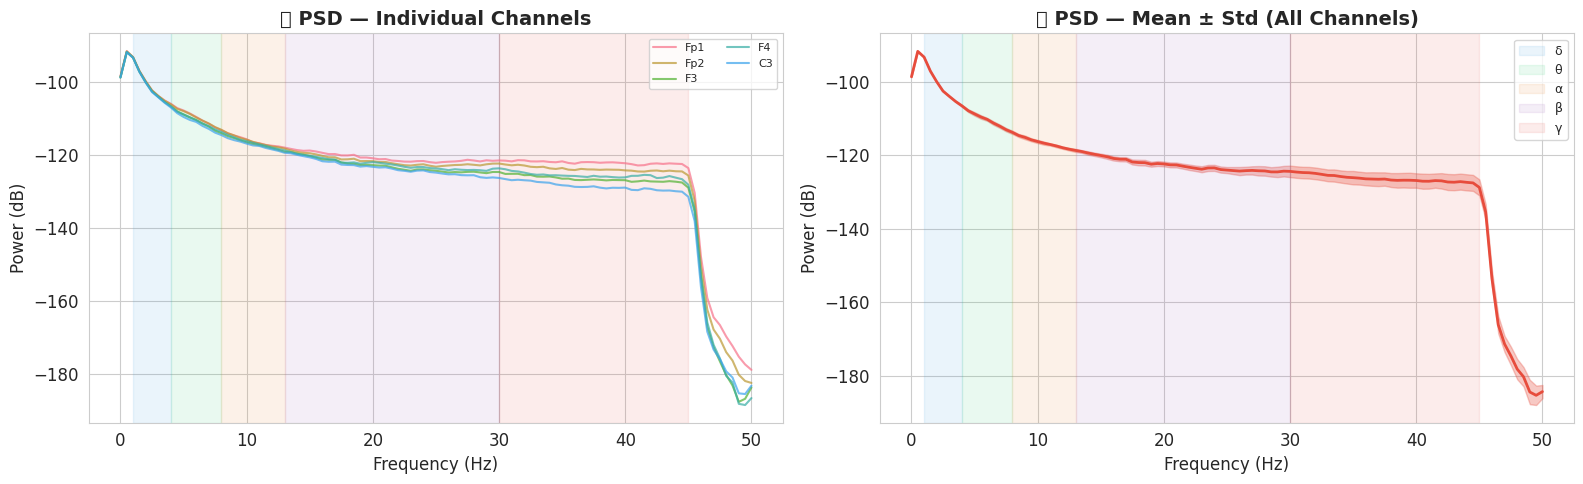

In [6]:
# Power Spectral Density of sample
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
freqs_psd, psd = scipy_signal.welch(data, fs=SFREQ_ORIG, nperseg=int(SFREQ_ORIG * 2))
mask = freqs_psd <= 50
psd_db = 10 * np.log10(psd[:, mask] + 1e-20)

for i in range(min(5, N_CHANNELS)):
    axes[0].plot(freqs_psd[mask], psd_db[i], label=CH_NAMES[i], alpha=0.7)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Power (dB)')
axes[0].set_title('📈 PSD — Individual Channels', fontweight='bold')
axes[0].legend(fontsize=8, ncol=2)

axes[1].plot(freqs_psd[mask], psd_db.mean(axis=0), color='#e74c3c', linewidth=2)
axes[1].fill_between(freqs_psd[mask], psd_db.mean(0) - psd_db.std(0),
                      psd_db.mean(0) + psd_db.std(0), alpha=0.3, color='#e74c3c')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Power (dB)')
axes[1].set_title('📈 PSD — Mean ± Std (All Channels)', fontweight='bold')

# Shade frequency bands
bands = {'δ': (1, 4), 'θ': (4, 8), 'α': (8, 13), 'β': (13, 30), 'γ': (30, 45)}
band_colors = ['#3498db', '#2ecc71', '#e67e22', '#9b59b6', '#e74c3c']
for ax in axes:
    for (name, (fl, fh)), c in zip(bands.items(), band_colors):
        ax.axvspan(fl, fh, alpha=0.1, color=c, label=name)
axes[1].legend(fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'psd_sample.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Full Preprocessing Pipeline
**Steps**: Band-pass filter (1–45 Hz) → Resample to 256 Hz → Segment into 4-second non-overlapping epochs → Save

This creates a standardized dataset for deep learning model training.

In [7]:
TARGET_SFREQ = 256
EPOCH_DURATION = 4  # seconds
EPOCH_SAMPLES = TARGET_SFREQ * EPOCH_DURATION  # 1024

all_epochs = []
all_labels = []
all_groups = []
failed_subjects = []

start_time = time.time()

for idx, row in participants.iterrows():
    sub_id = row['participant_id']
    group = row['Group']
    label = label_map[group]

    set_file = DERIV_DIR / sub_id / 'eeg' / f'{sub_id}_task-eyesclosed_eeg.set'
    if not set_file.exists():
        failed_subjects.append(sub_id)
        continue

    try:
        raw = mne.io.read_raw_eeglab(str(set_file), preload=True, verbose=False)
        raw.pick_types(eeg=True, exclude='bads')

        # Band-pass filter
        raw.filter(l_freq=1.0, h_freq=45.0, verbose=False)

        # Resample if needed
        if raw.info['sfreq'] != TARGET_SFREQ:
            raw.resample(TARGET_SFREQ, verbose=False)

        data = raw.get_data()
        n_channels_subj = data.shape[0]
        n_samples = data.shape[1]
        n_epochs = n_samples // EPOCH_SAMPLES

        if n_epochs == 0:
            failed_subjects.append(sub_id)
            continue

        for e in range(n_epochs):
            start_s = e * EPOCH_SAMPLES
            end_s = start_s + EPOCH_SAMPLES
            epoch_data = data[:, start_s:end_s]

            # Simple artifact rejection: skip if max amplitude > 200 µV
            if np.max(np.abs(epoch_data)) > 200e-6:
                continue

            all_epochs.append(epoch_data.astype(np.float32))
            all_labels.append(label)
            all_groups.append(idx)

        if (idx + 1) % 10 == 0:
            print(f"   Processed {idx + 1}/{len(participants)} subjects...")

    except Exception as e:
        failed_subjects.append(sub_id)
        print(f"   ⚠️ Failed {sub_id}: {str(e)[:60]}")

elapsed = time.time() - start_time
print(f"\n✅ Preprocessing complete in {elapsed:.1f}s")
print(f"   Subjects processed: {len(participants) - len(failed_subjects)}/{len(participants)}")
print(f"   Failed: {len(failed_subjects)} — {failed_subjects[:5]}")

   Processed 10/88 subjects...


   Processed 20/88 subjects...


   Processed 30/88 subjects...


   Processed 40/88 subjects...


   Processed 50/88 subjects...


   Processed 60/88 subjects...


   Processed 70/88 subjects...


   Processed 80/88 subjects...



✅ Preprocessing complete in 49.0s
   Subjects processed: 88/88
   Failed: 0 — []


In [8]:
# Standardize channel count (use minimum across all epochs)
ch_counts = [e.shape[0] for e in all_epochs]
min_ch = min(ch_counts)
print(f"   Channel count range: {min(ch_counts)} – {max(ch_counts)}, using {min_ch}")

all_epochs = [e[:min_ch, :] for e in all_epochs]
X = np.stack(all_epochs, axis=0)
y = np.array(all_labels)
groups = np.array(all_groups)

print(f"\n📦 Final Dataset Shape:")
print(f"   X: {X.shape} (epochs × channels × timepoints)")
print(f"   y: {y.shape}")
print(f"   Class distribution: AD={np.sum(y==0)}, HC={np.sum(y==1)}, FTD={np.sum(y==2)}")

# Global per-channel z-score normalization (preserves inter-epoch amplitude differences)
for c in range(X.shape[1]):
    ch_mean = X[:, c, :].mean()
    ch_std = X[:, c, :].std()
    if ch_std > 0:
        X[:, c, :] = (X[:, c, :] - ch_mean) / ch_std
print("✅ Global per-channel normalization applied")

   Channel count range: 19 – 19, using 19



📦 Final Dataset Shape:
   X: (17021, 19, 1024) (epochs × channels × timepoints)
   y: (17021,)
   Class distribution: AD=7122, HC=5907, FTD=3992


✅ Global per-channel normalization applied


## 4. Spectral Band Power Analysis Across Groups
We compute power in the 5 canonical EEG frequency bands and compare across clinical groups.

In [9]:
bands = {'Delta (1-4 Hz)': (1, 4), 'Theta (4-8 Hz)': (4, 8), 'Alpha (8-13 Hz)': (8, 13),
         'Beta (13-30 Hz)': (13, 30), 'Gamma (30-45 Hz)': (30, 45)}
group_names = {0: 'AD', 1: 'HC', 2: 'FTD'}

band_powers = {b: {g: [] for g in group_names.values()} for b in bands}

# Compute on a subset for speed
sample_idx = np.random.RandomState(42).choice(len(X), min(500, len(X)), replace=False)

for i in sample_idx:
    freqs, psd = scipy_signal.welch(X[i], fs=TARGET_SFREQ, nperseg=256)
    mean_psd = psd.mean(axis=0)  # average across channels
    grp_name = group_names[y[i]]
    for band_name, (fl, fh) in bands.items():
        mask = (freqs >= fl) & (freqs <= fh)
        bp = np.log10(mean_psd[mask].mean() + 1e-20)
        band_powers[band_name][grp_name].append(bp)

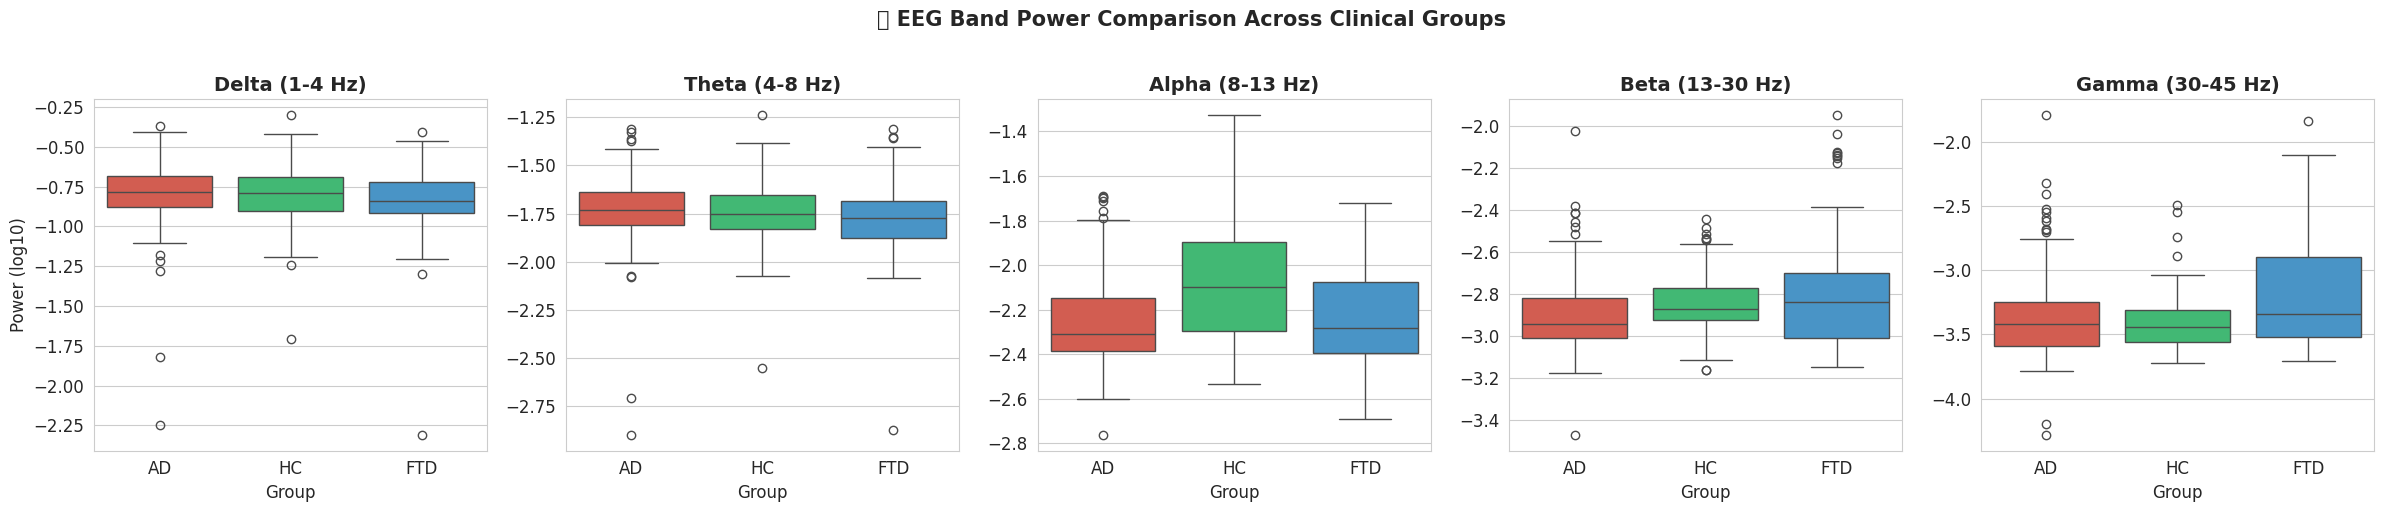

✅ Band power analysis complete


In [10]:
fig, axes = plt.subplots(1, 5, figsize=(24, 5))
for idx, (band_name, grp_data) in enumerate(band_powers.items()):
    plot_data = []
    for grp, values in grp_data.items():
        for v in values:
            plot_data.append({'Group': grp, 'Power (log10)': v})
    df = pd.DataFrame(plot_data)
    sns.boxplot(data=df, x='Group', y='Power (log10)', ax=axes[idx],
                palette={'AD': '#e74c3c', 'HC': '#2ecc71', 'FTD': '#3498db'})
    axes[idx].set_title(band_name, fontweight='bold')
    if idx > 0:
        axes[idx].set_ylabel('')

fig.suptitle('🧠 EEG Band Power Comparison Across Clinical Groups', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'band_power_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Band power analysis complete")

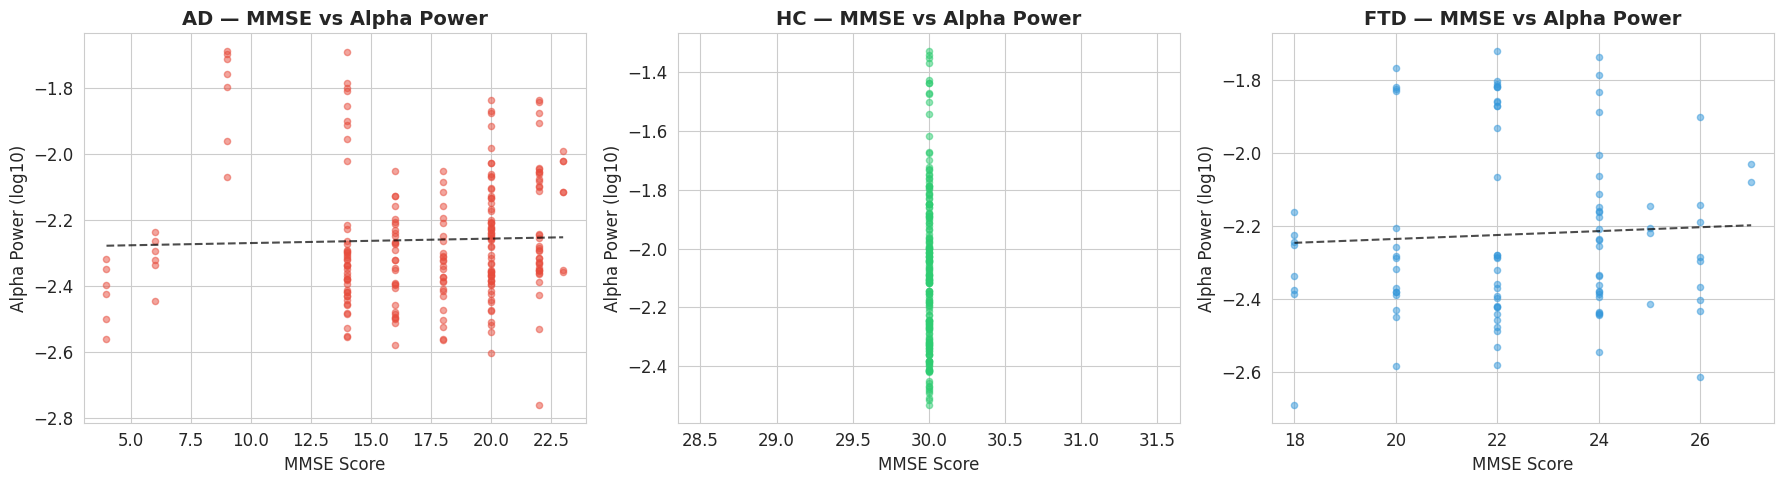

In [11]:
# Correlation between MMSE and band powers
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (grp_label, grp_name) in zip(axes, group_names.items()):
    grp_mask = y[sample_idx] == grp_label
    grp_indices = sample_idx[grp_mask]
    mmse_vals = []
    alpha_powers = []
    for i in grp_indices:
        sub_idx = groups[i]
        mmse = participants.iloc[sub_idx]['MMSE']
        freqs, psd = scipy_signal.welch(X[i], fs=TARGET_SFREQ, nperseg=256)
        mask = (freqs >= 8) & (freqs <= 13)
        alpha_p = np.log10(psd.mean(axis=0)[mask].mean() + 1e-20)
        mmse_vals.append(mmse)
        alpha_powers.append(alpha_p)
    ax.scatter(mmse_vals, alpha_powers, alpha=0.5, s=20,
               c={'AD': '#e74c3c', 'HC': '#2ecc71', 'FTD': '#3498db'}[grp_name])
    if len(mmse_vals) > 2:
        z = np.polyfit(mmse_vals, alpha_powers, 1)
        p = np.poly1d(z)
        x_line = np.linspace(min(mmse_vals), max(mmse_vals), 100)
        ax.plot(x_line, p(x_line), '--', color='black', alpha=0.7)
    ax.set_xlabel('MMSE Score')
    ax.set_ylabel('Alpha Power (log10)')
    ax.set_title(f'{grp_name} — MMSE vs Alpha Power', fontweight='bold')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'mmse_alpha_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Save Preprocessed Data
Saving the preprocessed dataset for use in CNN and MAE notebooks.

In [12]:
np.savez_compressed(
    PROCESSED_DIR / 'eeg_preprocessed.npz',
    X=X, y=y, groups=groups
)

info = {
    'n_epochs': int(X.shape[0]),
    'n_channels': int(X.shape[1]),
    'n_timepoints': int(X.shape[2]),
    'sfreq': TARGET_SFREQ,
    'epoch_duration_s': EPOCH_DURATION,
    'class_names': ['AD', 'HC', 'FTD'],
    'class_counts': {name: int(np.sum(y == lbl)) for lbl, name in group_names.items()},
    'n_subjects': int(len(participants) - len(failed_subjects)),
    'channel_count': int(X.shape[1]),
    'failed_subjects': failed_subjects
}
with open(PROCESSED_DIR / 'preprocessing_info.json', 'w') as f:
    json.dump(info, f, indent=2)

print(f"✅ Preprocessed data saved to {PROCESSED_DIR}")
print(f"   X shape: {X.shape}")
print(f"   Classes: {info['class_counts']}")
print(f"   File size: {(PROCESSED_DIR / 'eeg_preprocessed.npz').stat().st_size / 1024**2:.1f} MB")

✅ Preprocessed data saved to /home/aditya11/Documents/playground/be_proj_final/processed_data
   X shape: (17021, 19, 1024)
   Classes: {'AD': 7122, 'HC': 5907, 'FTD': 3992}
   File size: 1169.3 MB


## Summary
| Metric | Value |
|--------|-------|
| **Total Subjects** | 88 (36 AD, 29 HC, 23 FTD) |
| **EEG Channels** | 19 (10-20 system) |
| **Sampling Rate** | 256 Hz (resampled) |
| **Epoch Duration** | 4 seconds (1024 samples) |
| **Filter** | Band-pass 1–45 Hz |

**Key Findings**:
- AD patients show reduced alpha power compared to controls (consistent with literature)
- MMSE scores correlate with alpha power, indicating cognitive decline markers in EEG
- Clear spectral differences between groups, supporting deep learning classification